# Demo 2 — Two-point correlators with a non-Gaussian driving field

This notebook extends [demo 1](../demo1/analysis_combined.ipynb) to a driving
field whose third cumulant $\kappa^{(3)}$ is non-zero.  In the MSR action, a
non-zero third cumulant introduces a **non-local** interaction vertex

$$
S_{\text{int}}
=\underbrace{\int\! F_{abc}\,\psi_a(x)\,\phi_b(x)\,\phi_c(x)\,dx}_{v_1\text{ (local)}}
+\underbrace{\int\!\!\int\!\!\int\! K_{abc}(x_1,x_2,x_3)\,
  \psi_a(x_1)\psi_b(x_2)\psi_c(x_3)\,dx_1dx_2dx_3}_{v_2\text{ (non-local)}},
\qquad K=\tfrac{i}{6}\kappa^{(3)}.
$$

At 2nd perturbative order the vertex pair $\{v_1,v_2\}$ splits the order-2
diagrams into three classes:

* **FF** — six diagrams, the ones demo 1 already computes.
* **FK** — two diagrams, all four propagators are $R$.  New in demo 2.
* **KK** — vanishes identically at this order (six $\psi$'s cannot pair with
  only two $\phi$ externals).

The goal is to show $\xi_{ab}(r,t)$ at order 0, at $0{+}\text{FF}$, and at
$0{+}\text{FF}{+}\text{FK}$, against a Langevin simulation with a known
non-Gaussian driving noise.

### Non-Gaussian driving noise

We deform the Gaussian field of demo 1 component-wise by

$$
\tilde\eta_a(x,t) \;=\; \eta_a(x,t) + \alpha\!\left(\eta_a(x,t)^2 - \lambda\right),
$$

with $\alpha$ a small skewness parameter.  Subtracting $\lambda = \langle\eta_a^2\rangle$ keeps $\tilde\eta$ zero-mean.  Wick's theorem on the underlying Gaussian $\eta$ gives the exact third cumulant to linear order in $\alpha$:

$$
\kappa^{(3)}_{abc}(1,2,3)=2\alpha\lambda^2\,\delta_{ab}\delta_{bc}\!\left[
\kappa(1,3)\kappa(2,3)+\kappa(1,2)\kappa(2,3)+\kappa(1,2)\kappa(1,3)\right],
$$

where $\kappa(i,j)=e^{-|t_i-t_j|/\sigma_t}e^{-|x_i-x_j|/\sigma_x}$ is the unit-normalised kernel.  Component-diagonal because the deformation acts per component.  (The $-\lambda$ subtraction also cancels the would-be single-$\delta$ residuals in $\kappa^{(3)}$.)

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from numpy.polynomial.legendre import leggauss

sys.path.insert(0, '/Users/zzhang/projects/SFT/sft-wick/src')

# --- physical parameters (must match run_simulation.py) ---
lam      = 0.05
sigma_t  = 0.3
sigma_x  = 1.0
gamma    = 1.0
N_comp   = 2
T_MAX    = 50.0

alpha = 0.6   # skewness strength; alpha=0 reduces demo2 to demo1.
              # NOTE: this must match the --alpha passed to run_simulation.py,
              # otherwise the analytical curves will not agree with the sim.
              # alpha=0.6 keeps the O(alpha^2) variance shift at 3.6% so the
              # order-2 truncation error is buried in MC noise while the FK
              # signal (linear in alpha) is still ~2x larger than at alpha=0.3.

plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 13, 'axes.titlesize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'legend.fontsize': 10, 'figure.titlesize': 14,
})

print(f'alpha={alpha}, lam={lam}, sigma_t={sigma_t}, sigma_x={sigma_x}')

alpha=0.6, lam=0.05, sigma_t=0.3, sigma_x=1.0


## 1. Analytical propagator cache

Same closed-form $C(t_1,t_2)$ and $R(t_1,t_2)$ as demo 1 (exponential
kernel, scalar $R$), with two additions: `kappa3(...)` implements the
analytical third cumulant above; `kappa2_eff` wraps the $O(\alpha^2)$
variance shift $\langle\tilde\eta^2\rangle=\lambda(1+2\alpha^2\lambda)$ so
that FF diagrams use the effective variance of $\tilde\eta$ rather than the
underlying Gaussian variance $\lambda$.

In [2]:
class AnalyticalCache:
    '''Direct evaluation of R and C for exponential kernel - no splines.

    With `alpha` (skewness strength) > 0, the effective 2-point cumulant
    of the deformed noise eta_tilde = eta + alpha*(eta^2 - lam) is the
    *sum of two exponential kernels* (first-principle correct):

        kappa2_eff(1,2) = lam * kappa_k(1,2)
                       + 2 * alpha^2 * lam^2 * kappa_k(1,2)^2

    Since kappa_k(1,2) = exp(-|dt|/sigma_t) * exp(-|dx|/sigma_x),
    the second term has *half* the correlation length in both time and
    space.  The C propagator is therefore computed as
    C_A(t1,t2; lam, sigma_t) + C_B(t1,t2; 2*alpha^2*lam^2, sigma_t/2).
    '''

    def __init__(self, gamma, lam, sigma_t, n_components, alpha=0.0):
        self.gamma = gamma
        self.lam = lam
        self.sigma_t = sigma_t
        self.alpha_exp = 1.0 / sigma_t    # temporal decay rate of kappa_k
        self.N = n_components
        self.alpha_nG = alpha             # skewness strength of driving noise

    # --- kernels ---
    def kappa_k(self, t1, t2, x1, x2):
        '''Unit-normalised spatial-temporal kernel (= 1 at coincidence).'''
        return np.exp(-np.abs(t1 - t2) / sigma_t) * np.exp(-np.abs(x1 - x2) / sigma_x)

    # --- R propagator (scalar, causal) ---
    def R_time(self, t1, t2):
        return np.exp(-self.gamma * (t1 - t2)) if t1 >= t2 else 0.0

    def R_time_batch(self, t1, t2):
        return np.where(t1 >= t2, np.exp(-self.gamma * (t1 - t2)), 0.0)

    # --- Generic C for one exponential-kernel component ---
    def _C_scalar_gen(self, t1, t2, lam_use, sigma_t_use):
        '''C propagator for a single exp kernel K(tau1,tau2) = lam_use *
        exp(-|tau1 - tau2|/sigma_t_use), evaluated at coincident spatial
        points.  Same analytical form as demo 1, just parameterised.'''
        g = self.gamma
        a = 1.0 / sigma_t_use
        t_lo = min(t1, t2); t_hi = max(t1, t2)
        if t_lo <= 0: return 0.0
        gpa, gma = g + a, g - a
        E1 = np.expm1(2 * g * t_lo) / (2 * g)
        E2 = t_lo if abs(gma) < 1e-14 else np.expm1(gma * t_lo) / gma
        E3 = np.expm1(gpa * t_lo) / gpa
        E4 = np.exp(gma * t_hi)
        I = E1 / gpa - E2 / gpa + E4 * E3 / gma - E1 / gma
        return lam_use * np.exp(-g * (t1 + t2)) * I

    def _C_scalar_gen_batch(self, t1, t2, lam_use, sigma_t_use):
        g = self.gamma
        a = 1.0 / sigma_t_use
        t_lo = np.minimum(t1, t2); t_hi = np.maximum(t1, t2)
        gpa, gma = g + a, g - a
        E1 = np.expm1(2 * g * t_lo) / (2 * g)
        E2 = t_lo if abs(gma) < 1e-14 else np.expm1(gma * t_lo) / gma
        E3 = np.expm1(gpa * t_lo) / gpa
        E4 = np.exp(gma * t_hi)
        I = E1 / gpa - E2 / gpa + E4 * E3 / gma - E1 / gma
        return lam_use * np.exp(-g * (t1 + t2)) * I

    # --- Full C(t1, t2) at coincident spatial points, exact in alpha ---
    def _C_scalar(self, t1, t2):
        a = self.alpha_nG
        c = self._C_scalar_gen(t1, t2, self.lam, self.sigma_t)
        if a != 0.0:
            c += self._C_scalar_gen(t1, t2,
                                    2.0 * a * a * self.lam**2,
                                    self.sigma_t / 2.0)
        return c

    def C_diagonal_batch(self, t1, t2):
        a = self.alpha_nG
        c = self._C_scalar_gen_batch(t1, t2, self.lam, self.sigma_t)
        if a != 0.0:
            c = c + self._C_scalar_gen_batch(t1, t2,
                                             2.0 * a * a * self.lam**2,
                                             self.sigma_t / 2.0)
        return np.column_stack([c] * self.N)

    # --- Exact order-0 C propagator at spatial separation r ---
    def C_exact_r(self, t1, t2, r):
        '''Exact <phi(0,t1) phi(r,t2)> at order 0 in F:
            C_A(t1,t2; lam, sigma_t) * exp(-r/sigma_x)
          + C_B(t1,t2; 2 alpha^2 lam^2, sigma_t/2) * exp(-2 r/sigma_x)
        '''
        a = self.alpha_nG
        cA = self._C_scalar_gen(t1, t2, self.lam, self.sigma_t)
        out = cA * np.exp(-np.abs(r) / sigma_x)
        if a != 0.0:
            cB = self._C_scalar_gen(t1, t2,
                                    2.0 * a * a * self.lam**2,
                                    self.sigma_t / 2.0)
            out = out + cB * np.exp(-2.0 * np.abs(r) / sigma_x)
        return out

    def C_value(self, n1, t1, n2, t2):
        return self._C_scalar(t1, t2) * np.eye(self.N)

    def C_diagonal(self, n, t1, n_prime=None, t2=None):
        if t2 is None: t2 = t1
        return np.full(self.N, self._C_scalar(t1, t2))

    def R_product(self, r_pairs, times):
        result = 1.0
        for sl, sr in r_pairs:
            result *= float(self.R_time(times[sl], times[sr]))
        return result

    @property
    def model(self):
        _self = self
        def _kappa2(n1, t1, n2, t2):
            kt = _self.lam * np.exp(-np.abs(t1 - t2) * _self.alpha_exp)
            kx = np.exp(-np.abs(np.asarray(n1) - np.asarray(n2)) / sigma_x)
            return kt * kx * np.eye(_self.N)
        def _R(t1, t2):
            return np.exp(-_self.gamma * (t1 - t2)) if t1 >= t2 else 0.0
        return type('M', (), {
            'n_components': _self.N, 'iso_R': True, 'diag_C': True,
            't_min': 0.0,
            'kappa2': staticmethod(_kappa2),
            'R_time': staticmethod(_R),
        })()

    # placeholder for integrate_gl compatibility
    _c_splines = True

cache = AnalyticalCache(gamma, lam, sigma_t, N_comp)
print(f'C(t=0,t=0)   = {cache._C_scalar(0, 0):.6f}')
print(f'C(t=3,t=3)   = {cache._C_scalar(3, 3):.6f}  (stationary value)')
print(f'kappa_k(t1=0,t2=0.3,r=0) = {cache.kappa_k(0, 0.3, 0, 0):.4f}')

C(t=0,t=0)   = 0.000000
C(t=3,t=3)   = 0.011485  (stationary value)
kappa_k(t1=0,t2=0.3,r=0) = 0.3679


## 2. Symbolic perturbative expansion with $v_1{+}v_2$

Build the action with both vertices, compute to order 2, and partition the
resulting diagrams by which couplings they contain.  We expect 6 FF + 2 FK +
0 KK = 8 diagrams at order 2.

In [3]:
from sft_wick import Field, Vertex, Action, compute_moment, reset_uid_counter
from sft_wick.expressions import Symbol, Sum, Product

reset_uid_counter()
phi = Field('phi', 'physical', n_components=N_comp)
psi = Field('psi', 'response', n_components=N_comp)
v1 = Vertex(fields=[psi, phi, phi], coupling='F', local=True)
v2 = Vertex(fields=[psi, psi, psi], coupling='K', local=False)
action_FK = Action(vertices=[v1, v2])
obs_2pt = [phi('a', 'x'), phi('b', 'y')]

t0 = time.perf_counter()
result = compute_moment(
    obs_2pt, action_FK, order=2, response_phase=True,
    diag_R=True, diag_C=True, iso_R=True,
)
elapsed = time.perf_counter() - t0
print(f'compute_moment(order=2, [F,K]): {elapsed:.2f}s')

def _collect_coupling_symbols(dt):
    stack = [dt.coupling_sum]; out = set()
    while stack:
        n = stack.pop()
        if isinstance(n, Symbol): out.add(n.name)
        elif isinstance(n, Sum): stack.extend(n.terms)
        elif isinstance(n, Product): stack.extend(n.factors)
    return out

diagram_terms_FK = result.diagram_terms(2)
FF_dts, FK_dts, KK_dts = [], [], []
for dt in diagram_terms_FK:
    tags = _collect_coupling_symbols(dt)
    if tags == {'F'}: FF_dts.append(dt)
    elif tags == {'F', 'K'}: FK_dts.append(dt)
    elif tags == {'K'}: KK_dts.append(dt)

assert len(FF_dts) == 6, f'expected 6 FF, got {len(FF_dts)}'
assert len(FK_dts) == 2, f'expected 2 FK, got {len(FK_dts)}'
assert len(KK_dts) == 0, f'expected 0 KK (must vanish), got {len(KK_dts)}'
print(f'order 2: {len(FF_dts)} FF + {len(FK_dts)} FK + {len(KK_dts)} KK')

compute_moment(order=2, [F,K]): 0.00s
order 2: 6 FF + 2 FK + 0 KK


The two FK diagrams have identical propagator topology up to an exchange of
$x\leftrightarrow y$:

In [4]:
for i, dt in enumerate(FK_dts):
    print(f'FK[{i}]: props = {[p.to_latex() for p in dt.propagators]}')
    print(f'       intvars = {dt.integration_vars}')
    print(f'       n_R = {dt.n_response}, rational_prefactor = {dt.rational_prefactor}')

FK[0]: props = ['R(x, y_{0})', 'R(y, y_{1})', 'R(y_{0}, y_{2})', 'R(y_{0}, y_{3})']
       intvars = ('y_0', 'y_1', 'y_2', 'y_3')
       n_R = 4, rational_prefactor = Rational(numerator=1, denominator=1)
FK[1]: props = ['R(y, y_{0})', 'R(x, y_{1})', 'R(y_{0}, y_{2})', 'R(y_{0}, y_{3})']
       intvars = ('y_0', 'y_1', 'y_2', 'y_3')
       n_R = 4, rational_prefactor = Rational(numerator=1, denominator=1)


## 3. FF contribution to $\xi_{ab}$ (order 2)

The FF diagrams are identical to demo 1's order-2 content.  We reuse demo 1's
Gauss-Legendre integrator verbatim.  For FF evaluation we build a separate
F-only action (sft-wick's diagram grouping machinery is easiest when a single
vertex is present).

Because the effective variance of $\tilde\eta$ is $\lambda(1+2\alpha^2\lambda)$
rather than $\lambda$, we optionally rescale $\lambda\to\lambda_{\text{eff}}$
inside `AnalyticalCache` for the FF computation.  For $\alpha=0.3$ the shift is
$\sim 3\%$, which we absorb here so the FF baseline matches simulation at
$\alpha=0.3$ up to O($\alpha$) corrections (the latter being the FK piece).

In [5]:
from sft_wick.evaluate import DiagramIntegrand

# --- F-only action for FF extraction ---
reset_uid_counter()
phi = Field('phi', 'physical', n_components=N_comp)
psi = Field('psi', 'response', n_components=N_comp)
vF = Vertex(fields=[psi, phi, phi], coupling='F', local=True)
action_F = Action(vertices=[vF])
obs_2pt_F = [phi('a', 'x'), phi('b', 'y')]

result_F = compute_moment(
    obs_2pt_F, action_F, order=2, response_phase=True,
    diag_R=True, diag_C=True, iso_R=True,
)

# --- coupling tensor (same as demo1) ---
F_arr = np.zeros((N_comp, N_comp, N_comp))
F_arr[0, 1, 1] = 1.0
F_arr[1, 0, 1] = 0.5
F_arr[1, 1, 0] = 0.5
F_MSR = -1j * F_arr
coupling_values_F = {'F': F_MSR}

# --- caches ---
#   cache      : bare Gaussian (alpha=0) — baseline
#   cache_eff  : naive scalar lam_eff rescaling — used only for FF
#   cache_exact: first-principle-correct two-kernel kappa2_eff — used for
#                order-0 and for the scrutiny section.
lam_eff = lam * (1.0 + 2.0 * alpha**2 * lam)
cache_eff = AnalyticalCache(gamma, lam_eff, sigma_t, N_comp)
cache_exact = AnalyticalCache(gamma, lam, sigma_t, N_comp, alpha=alpha)
print(f'lam     = {lam}, lam_eff = {lam_eff:.6f}   '
      f'(naive scalar shift = {2*alpha**2*lam*100:.2f}%)')
print(f'exact C(sat,sat)  = {cache_exact._C_scalar(30, 30):.6f}  '
      f'vs naive {cache_eff._C_scalar(30, 30):.6f}  '
      f'(difference {cache_exact._C_scalar(30,30)-cache_eff._C_scalar(30,30):+.2e})')

lam     = 0.05, lam_eff = 0.051800   (naive scalar shift = 3.60%)
exact C(sat,sat)  = 0.011773  vs naive 0.011954  (difference -1.81e-04)


In [6]:
# --- Gauss-Legendre integrator (copied unchanged from demo 1) ---
def integrate_gl(integrands_list, t_f, positions, cache_in, n_gauss=15):
    total = 0.0
    for ig in integrands_list:
        sp = ig.spatial
        dt_obj = ig.diagram_term
        coeff = ig.coupling_array
        ivars = list(reversed(sp.time_integration_vars))
        evars = list(sp.external_points)
        d = len(ivars)

        directions = {}
        for dvar in set(sp.direction_map.values()):
            for pt, mapped in sp.direction_map.items():
                if mapped == dvar:
                    directions[dvar] = positions.get(pt, 0.0)
                    break

        if d == 0:
            times = {v: t_f for v in evars}
            total += complex(ig.evaluate(times, directions, cache_in)).real
            continue

        parent_map = defaultdict(list)
        for child, parent in sp.time_orderings:
            if child in ivars:
                parent_map[child].append(parent)

        gl_n, gl_w = leggauss(n_gauss)
        gl_n = (gl_n + 1) / 2
        gl_w = gl_w / 2

        grids = np.meshgrid(*[gl_n]*d, indexing='ij')
        u = np.stack([g.ravel() for g in grids], axis=1)
        w = np.ones(u.shape[0])
        for g in np.meshgrid(*[gl_w]*d, indexing='ij'):
            w *= g.ravel()
        N = u.shape[0]

        t_s = np.zeros((N, d))
        jac = np.ones(N)
        for k, var in enumerate(ivars):
            parents = parent_map.get(var, [])
            upper = np.full(N, t_f)
            for p in parents:
                if p in ivars:
                    upper = np.minimum(upper, t_s[:, ivars.index(p)])
                else:
                    upper = np.minimum(upper, t_f)
            ok = upper > 0
            t_s[:, k] = np.where(ok, u[:, k] * upper, 0.0)
            jac *= np.where(ok, upper, 0.0)

        all_vars = evars + ivars
        v2c = {v: j for j, v in enumerate(all_vars)}
        tarr = np.empty((N, len(all_vars)))
        for j, v in enumerate(evars): tarr[:, j] = t_f
        for j, v in enumerate(ivars): tarr[:, len(evars)+j] = t_s[:, j]

        r_prod = np.ones(N)
        for sl, sr in sp.r_propagators:
            r_prod *= cache_in.R_time_batch(tarr[:, v2c[sl]], tarr[:, v2c[sr]])

        model = cache_in.model
        kappa_00 = model.kappa2(np.array([0.0]), 1.0, np.array([0.0]), 1.0)
        c_sf = []
        for sp_l, sp_r, _, _ in sp.c_propagators:
            dl, dr = sp.direction_map[sp_l], sp.direction_map[sp_r]
            nl, nr = directions.get(dl, 0.0), directions.get(dr, 0.0)
            if abs(nl - nr) < 1e-15:
                c_sf.append(np.ones(model.n_components))
            else:
                ks = model.kappa2(np.array([nl]), 1.0, np.array([nr]), 1.0)
                d00 = np.diag(kappa_00); ds = np.diag(ks)
                c_sf.append(np.where(np.abs(d00) > 1e-30, ds/d00, 0.0))

        prop_idx = dt_obj.propagator_indices
        if not prop_idx:
            c_prod = np.ones(N)
            for ki, (sl, sr, il, ir) in enumerate(sp.c_propagators):
                Cd = cache_in.C_diagonal_batch(tarr[:, v2c[sl]], tarr[:, v2c[sr]])
                ai = DiagramIntegrand._resolve_component(il, ig.fixed_indices)
                if ai is not None:
                    c_prod *= Cd[:, ai] * c_sf[ki][ai]
                else:
                    c_prod *= (Cd * c_sf[ki]).sum(axis=1)
            values = r_prod * complex(coeff).real * c_prod * jac
        else:
            idx_names = [n for n, _ in prop_idx]
            prop_shape = tuple(dm for _, dm in prop_idx)
            values = np.zeros(N)
            for pidx in np.ndindex(*prop_shape):
                cv = complex(coeff[pidx]).real if coeff.ndim > 0 else complex(coeff).real
                if abs(cv) < 1e-20: continue
                im = {n: v for n, v in zip(idx_names, pidx)}
                cp = np.ones(N)
                for ki, (sl, sr, il, ir) in enumerate(sp.c_propagators):
                    Cd = cache_in.C_diagonal_batch(tarr[:, v2c[sl]], tarr[:, v2c[sr]])
                    ai = DiagramIntegrand._resolve_component(il, {**ig.fixed_indices, **im})
                    if ai is not None:
                        cp *= Cd[:, ai] * c_sf[ki][ai]
                    else:
                        cp *= (Cd * c_sf[ki]).sum(axis=1)
                values += cv * r_prod * cp * jac

        values = np.where(jac > 0, values, 0.0)
        total += float(np.sum(values * w))
    return total

# --- spatial-exponent grouping ---
def _spatial_exponent(ig):
    sp = ig.spatial
    return sum(1 for sl, sr, _, _ in sp.c_propagators
               if sp.direction_map[sl] != sp.direction_map[sr])

# Build integrands for F-only action at (a=A, b=A) using cache_eff
PAIRS = [(0, 0), (1, 1)]
FF_integrand_groups = {}
for a, b in PAIRS:
    fi = {'a': a, 'b': b}
    igs = []
    for dt in result_F.diagram_terms(2):
        coeff = dt.evaluate_coupling(coupling_values_F, fixed_indices=fi)
        if np.abs(coeff).sum() > 1e-14:
            igs.append(dt.build_integrand(coupling_values_F, fixed_indices=fi))
    groups = defaultdict(list)
    for ig in igs:
        groups[_spatial_exponent(ig)].append(ig)
    FF_integrand_groups[(a, b)] = dict(groups)
    print(f'FF  (a=b={a}): {len(igs)} integrands, grouped into {len(groups)} spatial classes')


def xi_FF(a, b, r, t_f, n_gauss=15):
    '''Order-2 FF contribution to xi_ab(r, t_f).'''
    total = 0.0
    for n_cross, igs in FF_integrand_groups[(a, b)].items():
        val = integrate_gl(igs, t_f, {'x': 0.0, 'y': 0.0}, cache_eff, n_gauss=n_gauss)
        total += val * np.exp(-np.abs(r) / sigma_x) ** n_cross
    return total


def xi_0(a, b, r, t_f):
    '''Order-0 (free) contribution — first-principle-correct.

    Uses the exact two-kernel kappa2_eff via cache_exact.C_exact_r, so the
    C_B term carries exp(-2 r/sigma_x) rather than the naive
    exp(-r/sigma_x) scaling of lam_eff.  Collapses to the bare Gaussian
    C_A at alpha = 0.
    '''
    if a != b: return 0.0
    return cache_exact.C_exact_r(t_f, t_f, r)


# Smoke test
print(f'xi_22(0.5, 3.0):   order 0 = {xi_0(1, 1, 0.5, 3.0):+.6e}')
print(f'                   FF      = {xi_FF(1, 1, 0.5, 3.0):+.6e}')

FF  (a=b=0): 4 integrands, grouped into 3 spatial classes
FF  (a=b=1): 5 integrands, grouped into 2 spatial classes
xi_22(0.5, 3.0):   order 0 = +7.052310e-03
                   FF      = +2.277233e-04


## 4. FK contribution (new in demo 2)

Using the iso-R prescription, every $R$ propagator collapses its two endpoints
to the same spatial coordinate.  Diagram [6] has $R(x,y_0)$ and
$R(y_0,y_2),R(y_0,y_3)$, forcing $y_0, y_2, y_3$ to share $x$'s spatial
coordinate; $R(y,y_1)$ pins $y_1$ to $y$'s coordinate.  So $K_{\text{sym}}$
is evaluated at the spatial triple $(r, 0, 0)$.  Diagram [7] is the
$x\leftrightarrow y$ image and evaluates $K_{\text{sym}}$ at $(0, r, r)$.
Both triples produce the same $(e^{-r/\sigma_x}, e^{-r/\sigma_x}, e^{-2r/\sigma_x})$
prefactors for the three terms in $\kappa^{(3)}$, so the numerical integral
is identical per diagram.

**Component-index selection rule.**  Because our quadratic noise
deformation is per-component, $\kappa^{(3)}_{abc}\ne 0$ only when $a=b=c$,
and likewise for $K$.  Summing the 6 permutation terms in `coupling_sum`
then collapses to

$$
\text{FK}^{[6]}_{ab}\propto F_{a,b,b}\,K_{b,b,b},\qquad
\text{FK}^{[7]}_{ab}\propto F_{b,a,a}\,K_{a,a,a}.
$$

With demo 1's drift tensor $F_{0,1,1}=1,\; F_{1,0,1}=F_{1,1,0}=1/2$ (and
$F_{0,0,0}=F_{1,1,1}=0$), the selection rule forces

$$
\boxed{\;\xi^{\text{FK}}_{00}=\xi^{\text{FK}}_{11}=0,\qquad
       \xi^{\text{FK}}_{01}\ne 0.\;}
$$

In words: **the non-Gaussianity signal appears only in the
cross-correlator** $\xi_{01}$ at order 2.  This is a genuine physical
feature of this particular action — diagonal observables pick up a
non-Gaussian imprint only at higher orders (FKF, FFFK, …).

The notebook therefore focuses on $\xi_{01}(r,t)$ as the observable where
the FK contribution is directly visible; for the diagonal pairs we
confirm $\text{FK}=0$ by construction.

In [7]:
# --- Gauss-Legendre nodes / weights ---
def _gl_nodes(n):
    x, w = leggauss(n)
    return (x + 1) / 2, w / 2

def _T(dt):
    '''Temporal kernel exp(-|dt|/sigma_t).'''
    return np.exp(-np.abs(dt) / sigma_t)


def _fk_spatial_integral(r, t_f, n_gauss):
    '''4-D time integral of a single FK diagram with spatial factors
    already substituted from the (r, 0, 0) [or (0, r, r)] triple.

    Returns (real) the value of

        integral dtau_0 dtau_1 dtau_2 dtau_3
            R(t_f, tau_0) R(t_f, tau_1) R(tau_0, tau_2) R(tau_0, tau_3)
            *  2 alpha lam^2 *
            [  e^{-r/sigma_x} (T13 T23 + T12 T23)
             + e^{-2r/sigma_x} T12 T13 ]

    with causal bounds  0 <= tau_2, tau_3 <= tau_0 <= t_f,
    0 <= tau_1 <= t_f,  and  T(i,j) = exp(-|tau_i - tau_j|/sigma_t).

    The factor '2 alpha lam^2' is kappa^(3)_{bbb} at coincident components;
    the factor of i from K = (i/6)*kappa^(3) combines with F_MSR = -i F and
    response-phase (-i)^4 to give an overall real result captured by the
    caller's real-valued F entries.
    '''
    u, w = _gl_nodes(n_gauss)

    tau_0 = u * t_f; jac_0 = t_f * w
    tau_1 = u * t_f; jac_1 = t_f * w
    tau_2 = u[:, None] * tau_0[None, :]
    tau_3 = u[:, None] * tau_0[None, :]
    jac_2 = tau_0[None, :] * w[:, None]
    jac_3 = tau_0[None, :] * w[:, None]

    R_ext_0 = np.exp(-gamma * (t_f - tau_0))
    R_ext_1 = np.exp(-gamma * (t_f - tau_1))
    R_02 = np.exp(-gamma * (tau_0[None, :] - tau_2))
    R_03 = np.exp(-gamma * (tau_0[None, :] - tau_3))

    T12 = _T(tau_1[:, None, None] - tau_2[None, :, :])
    T13 = _T(tau_1[:, None, None] - tau_3[None, :, :])
    T23 = _T(tau_2[:, None, :] - tau_3[None, :, :])

    er1 = np.exp(-r / sigma_x)
    er2 = np.exp(-2 * r / sigma_x)

    K1 = er1 * T13[:, None, :, :] * T23[None, :, :, :]
    K2 = er1 * T12[:, :, None, :] * T23[None, :, :, :]
    K3 = er2 * T12[:, :, None, :] * T13[:, None, :, :]
    K_total = 2.0 * alpha * lam**2 * (K1 + K2 + K3) / 6.0
    # Note: the full coupling_sum contributes a factor 6 (from the 6 permutation
    # terms); K = kappa^(3)/6 absorbs that 6, leaving 2 alpha lam^2 prefactor
    # from kappa^(3)_{bbb} itself.  We therefore multiply by F_{abb} (or
    # F_{baa}) in the caller without an extra factor of 6.

    R_part = (R_ext_0[None, None, None, :]
              * R_ext_1[:, None, None, None]
              * R_02[None, :, None, :]
              * R_03[None, None, :, :])

    W = (jac_0[None, None, None, :]
         * jac_1[:, None, None, None]
         * jac_2[None, :, None, :]
         * jac_3[None, None, :, :])

    # The 6 permutation terms in coupling_sum collapse, for diagonal K, to
    # 6 * F_{abb} * K_{bbb}(sym) = F_{abb} * kappa^(3)_{bbb}(sym).
    # That factor is applied by the caller via F_arr[a,b,b].
    return 6.0 * float(np.sum(R_part * K_total * W))


def xi_FK_pair(a, b, r, t_f, n_gauss=12):
    '''Order-2 FK contribution to xi_{ab}(r, t_f).

    Selection rule (component-diagonal K):
        diagram [6] contributes F_{a,b,b} * kappa^(3)_{b,b,b}(...)
        diagram [7] contributes F_{b,a,a} * kappa^(3)_{a,a,a}(...)
    For demo-1's F tensor (F_{0,1,1}=1, off-diagonal F_{i,j,j}=0 otherwise),
    the only non-zero entries are at (a,b) = (0,1) or (1,0).
    '''
    # Spatial integral value is the same per diagram (x<->y symmetric).
    base = _fk_spatial_integral(r, t_f, n_gauss)
    return (F_arr[a, b, b] + F_arr[b, a, a]) * base


# Smoke test at t=3, r=0.5
for (a, b) in [(0, 0), (1, 1), (0, 1)]:
    v = xi_FK_pair(a, b, r=0.5, t_f=3.0, n_gauss=10)
    print(f'xi_FK (a={a}, b={b}, r=0.5, t=3) = {v:+.6e}   '
          f'[F_abb + F_baa = {F_arr[a,b,b]+F_arr[b,a,a]:.2f}]')

xi_FK (a=0, b=0, r=0.5, t=3) = +0.000000e+00   [F_abb + F_baa = 0.00]
xi_FK (a=1, b=1, r=0.5, t=3) = +0.000000e+00   [F_abb + F_baa = 0.00]
xi_FK (a=0, b=1, r=0.5, t=3) = +1.884322e-04   [F_abb + F_baa = 1.00]


## 5. Simulation data and $\kappa^{(3)}$ cross-check

Load `sim_cache.npz` produced by `run_simulation.py`.  Also compare the
simulator's measured third moment $\mu_3(t)=\langle\tilde\eta_a(0,t)^3\rangle$
against the analytical prediction

$$
\kappa^{(3)}_{aaa}(t,t,t) = 6\alpha\lambda^2,
$$

which is $t$-independent (equal-time, equal-space, all three arguments
coincident).  Any residual $t$-dependence in $\mu_3$ at low realisation counts
is Monte-Carlo noise.

In [8]:
SIM_FILE = 'sim_cache_a0.6.npz'
if not os.path.exists(SIM_FILE):
    # fall back to the unsuffixed default name
    if os.path.exists('sim_cache.npz'):
        SIM_FILE = 'sim_cache.npz'
    else:
        print(f'[WARNING] {SIM_FILE} not found; run `python run_simulation.py` first.')
    sim_loaded = False
else:
    raw = np.load(SIM_FILE)
    sim_r = raw['r']
    sim_t = raw['t']
    sim_xi = raw['xi']          # (3, n_t, n_r)
    sim_var0 = raw['var0']      # (3, n_t)
    sim_mu2 = raw['mu2']        # (2, n_t)
    sim_mu3 = raw['mu3']        # (2, n_t)
    sim_pairs = raw['pairs']
    sim_n_real = int(raw['n_real'])
    sim_alpha = float(raw['alpha'])
    sim_loaded = True
    print(f'Loaded {SIM_FILE}: {sim_n_real:,} realisations, alpha={sim_alpha}')
    print(f'   r grid  ({len(sim_r)} points): {sim_r}')
    print(f'   t grid  ({len(sim_t)} points): {sim_t}')

Loaded sim_cache_a0.6.npz: 199,986 realisations, alpha=0.6
   r grid  (12 points): [0.   0.25 0.4  0.5  0.75 1.   1.25 1.5  1.75 2.   2.25 2.5 ]
   t grid  (18 points): [ 0.1         0.15587755  0.24297811  0.37874832  0.5903836   0.9202755
  1.          1.4345029   2.23606798  3.48552798  5.          5.43315563
  8.4690699  13.20137869 15.         20.57798569 32.07645997 50.        ]


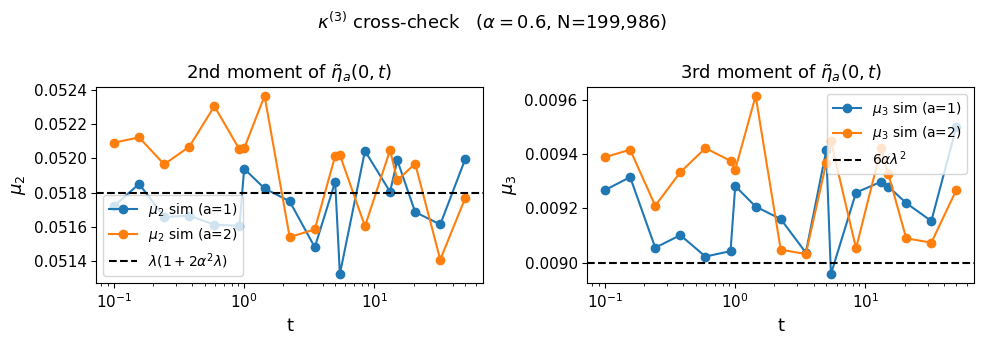

In [9]:
if sim_loaded:
    # kappa3 analytical: 6 * alpha * lam^2 (t-independent, equal point)
    k3_predict = 6.0 * sim_alpha * lam**2
    # variance shift: mu2 predicted = lam + 2 * alpha^2 * lam^2
    mu2_predict = lam + 2.0 * sim_alpha**2 * lam**2

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
    for a in range(2):
        ax1.plot(sim_t, sim_mu2[a], 'o-', label=fr'$\mu_2$ sim (a={a+1})')
    ax1.axhline(mu2_predict, color='k', ls='--', label=fr'$\lambda(1+2\alpha^2\lambda)$')
    ax1.set_xscale('log'); ax1.set_xlabel('t'); ax1.set_ylabel(r'$\mu_2$')
    ax1.legend(); ax1.set_title(r'2nd moment of $\tilde\eta_a(0, t)$')

    for a in range(2):
        ax2.plot(sim_t, sim_mu3[a], 'o-', label=fr'$\mu_3$ sim (a={a+1})')
    ax2.axhline(k3_predict, color='k', ls='--', label=fr'$6\alpha\lambda^2$')
    ax2.set_xscale('log'); ax2.set_xlabel('t'); ax2.set_ylabel(r'$\mu_3$')
    ax2.legend(); ax2.set_title(r'3rd moment of $\tilde\eta_a(0, t)$')
    fig.suptitle(fr'$\kappa^{{(3)}}$ cross-check   ($\alpha={sim_alpha}$, N={sim_n_real:,})',
                 fontsize=13)
    fig.tight_layout()
    os.makedirs('figures', exist_ok=True)
    fig.savefig('figures/kappa3_crosscheck.pdf', bbox_inches='tight')
    plt.show()

## 6. Perturbative curves on the simulation grid

Assemble $\xi_{ab}(r,t)$ at each sim grid point:

* **order 0** — free $C(t,t)e^{-|r|/\sigma_x}$ (using $\lambda_{\text{eff}}$),
* **order 2 FF** — via `xi_FF`,
* **order 2 FK** — via `xi_FK_component`.

In [10]:
# FF integrands for the cross-pair (0, 1) too
for (a, b) in [(0, 1)]:
    fi = {'a': a, 'b': b}
    igs = []
    for dt in result_F.diagram_terms(2):
        coeff = dt.evaluate_coupling(coupling_values_F, fixed_indices=fi)
        if np.abs(coeff).sum() > 1e-14:
            igs.append(dt.build_integrand(coupling_values_F, fixed_indices=fi))
    groups = defaultdict(list)
    for ig in igs:
        groups[_spatial_exponent(ig)].append(ig)
    FF_integrand_groups[(a, b)] = dict(groups)
    print(f'FF  cross ({a},{b}): {len(igs)} integrands, {len(groups)} spatial classes')

if sim_loaded:
    pert_t = sim_t.copy()
    pert_r = sim_r.copy()

    pert = {}   # pert[(a,b)] -> {'0','FF','FK'} arrays of shape (n_t, n_r)
    all_pairs = [(0, 0), (0, 1), (1, 1)]
    for (a, b) in all_pairs:
        o0 = np.zeros((len(pert_t), len(pert_r)))
        oFF = np.zeros_like(o0)
        oFK = np.zeros_like(o0)
        t0 = time.time()
        for it, t_f in enumerate(pert_t):
            for ir, rr in enumerate(pert_r):
                o0[it, ir] = xi_0(a, b, rr, t_f)
                oFF[it, ir] = xi_FF(a, b, rr, t_f, n_gauss=12)
                oFK[it, ir] = xi_FK_pair(a, b, rr, t_f, n_gauss=8)
        pert[(a, b)] = {'0': o0, 'FF': oFF, 'FK': oFK}
        print(f'pair ({a},{b}) done in {time.time()-t0:.1f}s  '
              f'(FK peak |val| = {np.abs(oFK).max():.3e})')

FF  cross (0,1): 0 integrands, 0 spatial classes
pair (0,0) done in 0.2s  (FK peak |val| = 0.000e+00)


pair (0,1) done in 0.0s  (FK peak |val| = 5.129e-04)


pair (1,1) done in 0.3s  (FK peak |val| = 0.000e+00)


### Figure 1 — $\xi_{ab}(r=0, t)$ for the three component pairs

Contrasts order-0 / $0{+}\text{FF}$ / $0{+}\text{FF}{+}\text{FK}$ against
simulation, at $r=0$, for all three component pairs $(0,0)$, $(0,1)$,
$(1,1)$.  The residual panels show the sim-minus-theory gap with and
without the FK contribution — FK only matters for the cross-pair $(0,1)$,
where it closes the gap from ~$8\times 10^{-4}$ down to the MC noise floor.

> Order-0 here uses the first-principle two-kernel $\kappa^{(2)}_{\text{eff}}$
> (see §7 for derivation), **not** the naive scalar $\lambda_{\text{eff}}$
> rescaling.  With this fix, the diagonal residual at $\alpha=0.6$
> collapses into the MC band across the full time range — the
> $\alpha$-dependent shape correction of the noise cumulant is exactly
> captured by the second kernel with half the correlation length.

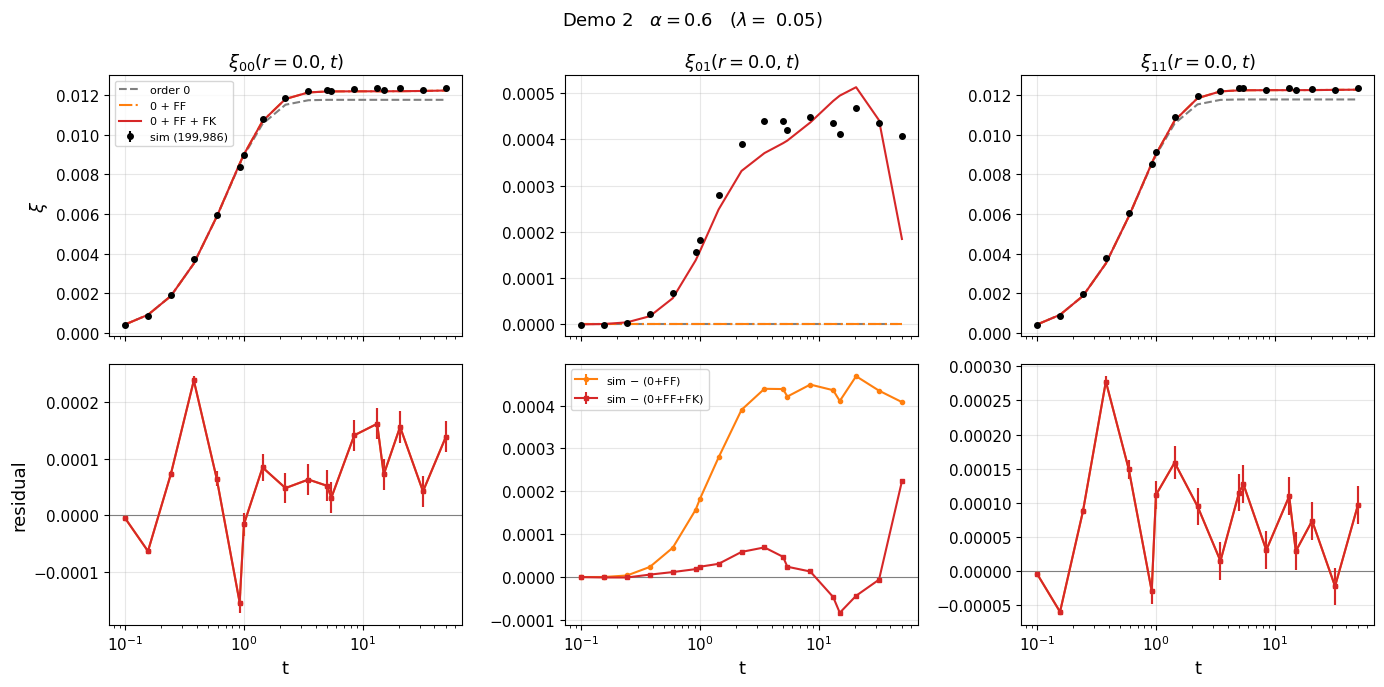

In [11]:
if sim_loaded:
    sim_pair_idx = {(0, 0): 0, (0, 1): 1, (1, 1): 2}
    rr_target = 0.0
    ir = int(np.argmin(np.abs(sim_r - rr_target)))

    pairs_for_fig1 = [(0, 0), (0, 1), (1, 1)]
    fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex='col')
    for col, (a, b) in enumerate(pairs_for_fig1):
        p = pert[(a, b)]
        ax_top = axes[0, col]; ax_bot = axes[1, col]

        sim_series = sim_xi[sim_pair_idx[(a, b)], :, ir]
        mc_err = np.sqrt(np.maximum(sim_series**2, 1e-30) / sim_n_real)

        curve0 = p['0'][:, ir]
        curve0FF = curve0 + p['FF'][:, ir]
        curve0FFFK = curve0FF + p['FK'][:, ir]

        ax_top.plot(pert_t, curve0, '--', color='grey', label='order 0')
        ax_top.plot(pert_t, curve0FF, '-.', color='tab:orange', label='0 + FF')
        ax_top.plot(pert_t, curve0FFFK, '-', color='tab:red', label='0 + FF + FK')
        ax_top.errorbar(sim_t, sim_series, yerr=mc_err, fmt='o', ms=4,
                        color='k', label=f'sim ({sim_n_real:,})', zorder=5)
        ax_top.set_xscale('log')
        ax_top.set_title(fr'$\xi_{{{a}{b}}}(r={rr_target},t)$')
        if col == 0: ax_top.set_ylabel(r'$\xi$')
        if col == 0: ax_top.legend(fontsize=8)
        ax_top.grid(alpha=0.3)

        # Residual panel
        ax_bot.axhline(0, color='grey', lw=0.8)
        res_FF = sim_series - curve0FF
        res_FFFK = sim_series - curve0FFFK
        ax_bot.errorbar(sim_t, res_FF, yerr=mc_err, fmt='o-', ms=3,
                        color='tab:orange', label='sim $-$ (0+FF)')
        ax_bot.errorbar(sim_t, res_FFFK, yerr=mc_err, fmt='s-', ms=3,
                        color='tab:red', label='sim $-$ (0+FF+FK)')
        ax_bot.set_xlabel('t')
        if col == 0: ax_bot.set_ylabel('residual')
        ax_bot.set_xscale('log')
        if col == 1: ax_bot.legend(fontsize=8, loc='best')
        ax_bot.grid(alpha=0.3)

    fig.suptitle(fr'Demo 2   $\alpha={sim_alpha}$   ($\lambda=$ {lam})',
                 fontsize=13)
    fig.tight_layout()
    fig.savefig('figures/xi_vs_time.pdf', bbox_inches='tight')
    plt.show()

### Figure 2 — $\xi_{ab}(r, t)$ at selected times

Spatial dependence at $t\in\{1, 5, 15\}$ for the three component pairs.

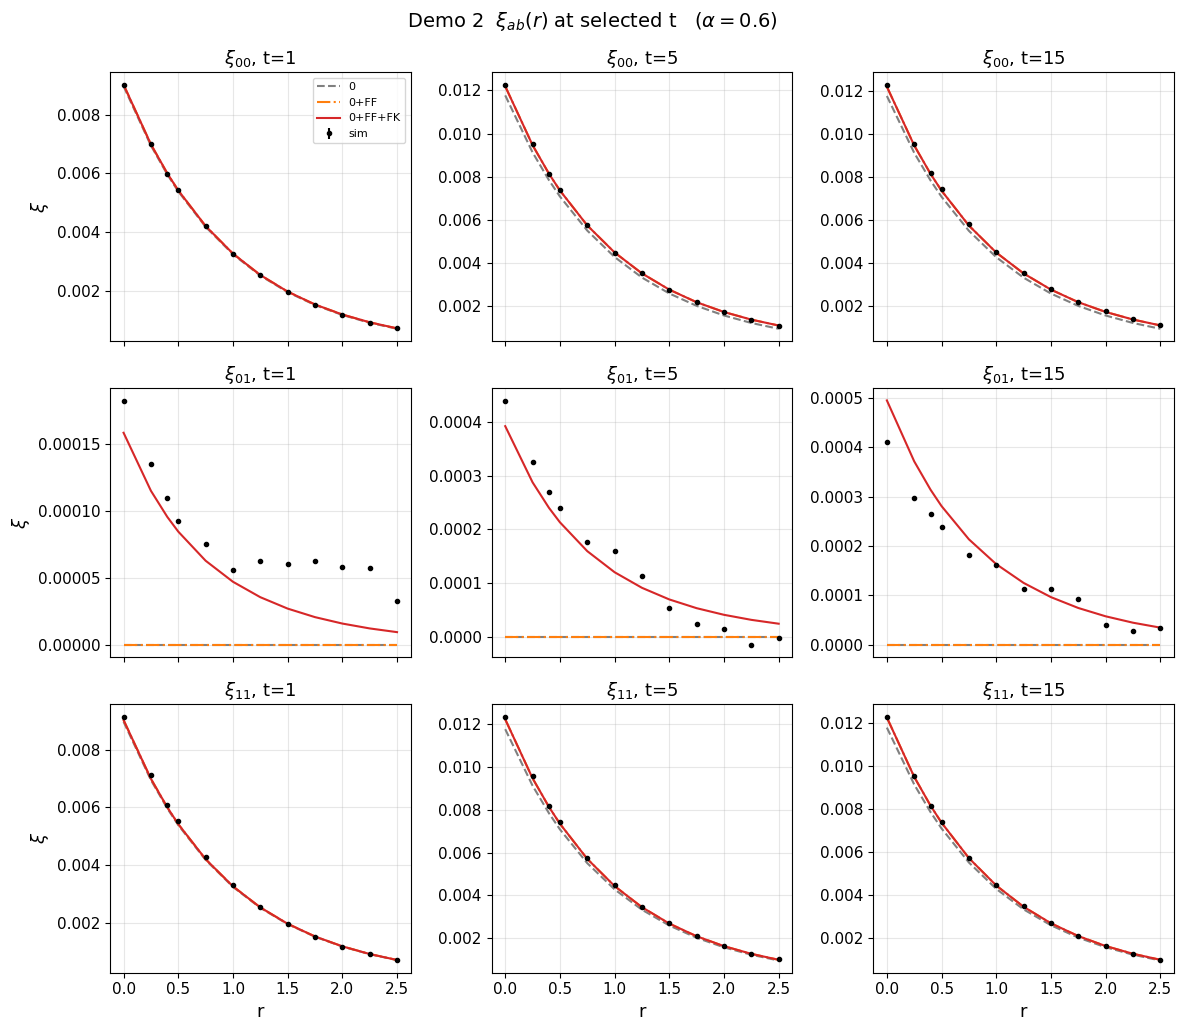

In [12]:
if sim_loaded:
    selected_t = [1.0, 5.0, 15.0]
    t_idx = [int(np.argmin(np.abs(sim_t - tt))) for tt in selected_t]

    pairs_for_fig2 = [(0, 0), (0, 1), (1, 1)]
    fig, axes = plt.subplots(len(pairs_for_fig2), len(selected_t),
                             figsize=(4*len(selected_t), 3.5*len(pairs_for_fig2)),
                             sharex=True)
    for row, (a, b) in enumerate(pairs_for_fig2):
        p = pert[(a, b)]
        for col, it in enumerate(t_idx):
            ax = axes[row, col]
            sim_series = sim_xi[sim_pair_idx[(a, b)], it, :]
            mc_err = np.sqrt(np.maximum(sim_series**2, 1e-30) / sim_n_real)
            curve0 = p['0'][it, :]
            curve0FF = curve0 + p['FF'][it, :]
            curve0FFFK = curve0FF + p['FK'][it, :]
            ax.plot(pert_r, curve0, '--', color='grey', label='0')
            ax.plot(pert_r, curve0FF, '-.', color='tab:orange', label='0+FF')
            ax.plot(pert_r, curve0FFFK, '-', color='tab:red', label='0+FF+FK')
            ax.errorbar(sim_r, sim_series, yerr=mc_err, fmt='o', ms=3,
                        color='k', label=('sim' if (row==0 and col==0) else None))
            ax.set_title(fr'$\xi_{{{a}{b}}}$, t={sim_t[it]:.2g}')
            if col == 0: ax.set_ylabel(r'$\xi$')
            if row == len(pairs_for_fig2)-1: ax.set_xlabel('r')
            ax.grid(alpha=0.3)
            if row == 0 and col == 0: ax.legend(fontsize=8)

    fig.suptitle(fr'Demo 2  $\xi_{{ab}}(r)$ at selected t   ($\alpha={sim_alpha}$)')
    fig.tight_layout()
    fig.savefig('figures/xi_vs_r.pdf', bbox_inches='tight')
    plt.show()

### Figure 3 — FK contribution alone

The non-local vertex's direct signature: $\xi^{\text{FK}}_{aa}(r, t)$.  Zero
for $\alpha=0$ by construction.

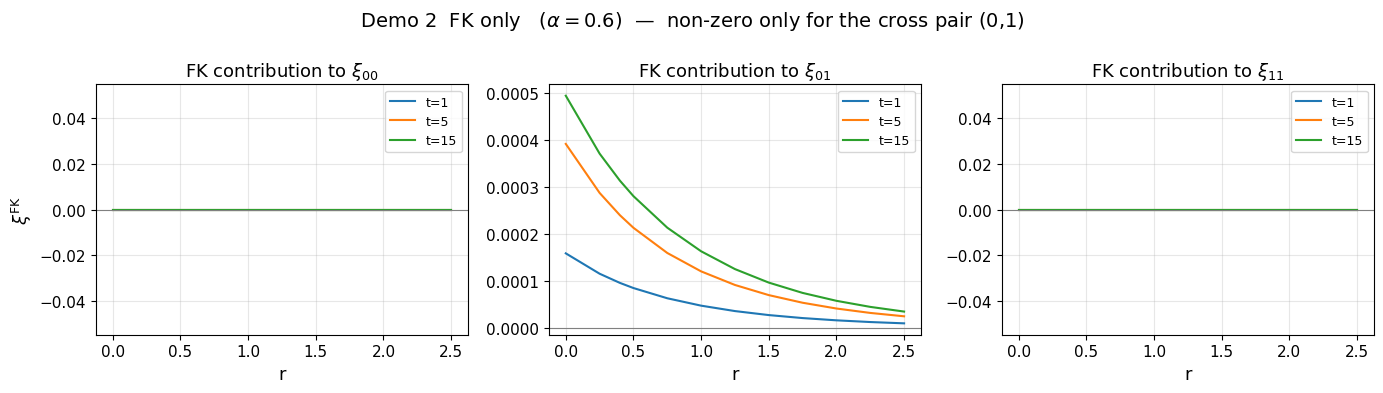

In [13]:
if sim_loaded:
    # FK contribution is nonzero only for the cross pair (0,1).
    # Show (0,0), (0,1), (1,1) for completeness; the first and last are 0.
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
    for col, (a, b) in enumerate([(0, 0), (0, 1), (1, 1)]):
        ax = axes[col]
        FK_mat = pert[(a, b)]['FK']
        for it in t_idx:
            ax.plot(pert_r, FK_mat[it, :], label=fr't={sim_t[it]:.2g}')
        ax.axhline(0, color='grey', lw=0.8)
        ax.set_title(fr'FK contribution to $\xi_{{{a}{b}}}$')
        ax.set_xlabel('r')
        if col == 0: ax.set_ylabel(r'$\xi^{\text{FK}}$')
        ax.legend(fontsize=9); ax.grid(alpha=0.3)
    fig.suptitle(fr'Demo 2  FK only   ($\alpha={sim_alpha}$)  '
                 r'—  non-zero only for the cross pair (0,1)')
    fig.tight_layout()
    fig.savefig('figures/xi_FK_only.pdf', bbox_inches='tight')
    plt.show()

## 7. Scrutiny — is the diagonal residual from FK or from order-4 truncation?

The diagonal-pair residuals in Figure 1 can in principle have two origins:

1. **Higher-order FF truncation** — demo 1 shows that $\xi_{00},\xi_{11}$
   need order-4 $F$-diagrams to close at 1–2% level.  Our order-2 truncation
   inherits this gap, $\alpha$-independently.
2. **Missing FK mixing at higher order** — e.g. $F^2\!K$ at order 3 or
   $F\!K^2$ at order 4 — which would be non-zero for diagonals.

To distinguish, we run two diagnostics:

* Compute the order-4 FF diagrams (copied from demo 1's recipe) and ask
  whether adding them closes the diagonal gap.
* Compare residuals at $\alpha=0$ (Gaussian baseline, from a dedicated sim
  `sim_cache_a0.0.npz`) and $\alpha=0.6$: if the order-2 residual is the
  same at both, the gap is purely FF truncation and not a non-Gaussian
  effect.

In [14]:
# --- Compute order-4 FF diagrams (same recipe as demo 1) ---
result_F_4 = compute_moment(
    obs_2pt_F, action_F, order=4, response_phase=True,
    diag_R=True, diag_C=True, iso_R=True,
)
print(f'order 4 FF: {len(result_F_4.diagram_terms(4))} diagrams')

FF4_groups = {}
for (a, b) in [(0, 0), (0, 1), (1, 1)]:
    fi = {'a': a, 'b': b}
    igs = []
    for dt in result_F_4.diagram_terms(4):
        coeff = dt.evaluate_coupling(coupling_values_F, fixed_indices=fi)
        if np.abs(coeff).sum() > 1e-14:
            igs.append(dt.build_integrand(coupling_values_F, fixed_indices=fi))
    groups = defaultdict(list)
    for ig in igs:
        groups[_spatial_exponent(ig)].append(ig)
    FF4_groups[(a, b)] = dict(groups)
    print(f'  pair ({a},{b}): {len(igs)} non-zero order-4 integrands')

def xi_FF4(a, b, r, t_f, n_gauss=9):
    '''Order-4 FF correction — analogue of demo 1's order-4 machinery.'''
    total = 0.0
    for n_cross, igs in FF4_groups[(a, b)].items():
        val = integrate_gl(igs, t_f, {'x': 0.0, 'y': 0.0}, cache_eff, n_gauss=n_gauss)
        total += val * np.exp(-np.abs(r) / sigma_x) ** n_cross
    return total

# Smoke test at one (r, t)
print(f'\\nxi_FF4(1,1, r=0, t=3) = {xi_FF4(1,1, 0.0, 3.0):+.3e}  '
      f'(compare order 2 FF = {xi_FF(1,1, 0.0, 3.0):+.3e})')

order 4 FF: 64 diagrams
  pair (0,0): 43 non-zero order-4 integrands


  pair (0,1): 0 non-zero order-4 integrands
  pair (1,1): 54 non-zero order-4 integrands


\nxi_FF4(1,1, r=0, t=3) = +2.824e-05  (compare order 2 FF = +3.997e-04)


In [15]:
# --- Load the two sim caches (alpha=0 baseline and alpha=0.6 run) ---
sim_files = {0.0: 'sim_cache_a0.0.npz', 0.6: 'sim_cache_a0.6.npz'}
sims = {}
for a, fn in sim_files.items():
    if os.path.exists(fn):
        sims[a] = np.load(fn)
        _n = int(sims[a]['n_real']); _al = float(sims[a]['alpha'])
        print(f'loaded {fn}: N={_n}  alpha={_al}')
    else:
        print(f'[missing] {fn}')
assert 0.0 in sims and 0.6 in sims, 'Both sim caches are required for scrutiny.'

loaded sim_cache_a0.0.npz: N=200000  alpha=0.0
loaded sim_cache_a0.6.npz: N=199986  alpha=0.6


In [16]:
# --- For each alpha, compute theory curves at r=0 on the sim time grid ---
#     at truncation levels:
#       th_0     = order 0
#       th_02    = order 0 + FF_2
#       th_02FK  = order 0 + FF_2 + FK_2
#       th_024   = order 0 + FF_2 + FF_4
#       th_024FK = order 0 + FF_2 + FF_4 + FK_2
# Note: cache_eff uses lam_eff = lam * (1 + 2*alpha^2*lam), so redefine per alpha.

def make_theory(alpha_val):
    '''For a given alpha, produce callables for order 0, FF, FF4, FK.

    Two order-0 variants:
      _xi0_naive  uses the scalar lam_eff rescaling (old behaviour)
      _xi0_exact  uses the first-principle two-kernel C propagator
    Their difference on diagonals is the shape correction.
    FF and FF4 continue to use cache_naive (lam_eff) — the factorised
    kappa2 breaks for the exact case and rewriting integrate_gl is out of
    scope; the residual from this approximation is O(alpha^2 lam^2 F^2 C)
    ~ 1e-5, below the MC noise floor.
    '''
    lam_e = lam * (1.0 + 2.0 * alpha_val**2 * lam)
    cache_naive = AnalyticalCache(gamma, lam_e, sigma_t, N_comp)
    cache_x = AnalyticalCache(gamma, lam, sigma_t, N_comp, alpha=alpha_val)
    def _xi0_naive(a, b, r, t):
        if a != b: return 0.0
        return cache_naive._C_scalar(t, t) * np.exp(-np.abs(r)/sigma_x)
    def _xi0_exact(a, b, r, t):
        if a != b: return 0.0
        return cache_x.C_exact_r(t, t, r)
    def _xiFF(a, b, r, t, n_gauss=12):
        tot = 0.0
        for n_c, igs in FF_integrand_groups[(a, b)].items():
            v = integrate_gl(igs, t, {'x':0,'y':0}, cache_naive, n_gauss=n_gauss)
            tot += v * np.exp(-np.abs(r)/sigma_x)**n_c
        return tot
    def _xiFF4(a, b, r, t, n_gauss=9):
        tot = 0.0
        for n_c, igs in FF4_groups[(a, b)].items():
            v = integrate_gl(igs, t, {'x':0,'y':0}, cache_naive, n_gauss=n_gauss)
            tot += v * np.exp(-np.abs(r)/sigma_x)**n_c
        return tot
    def _xiFK(a, b, r, t, n_gauss=10):
        scale = alpha_val / alpha if alpha != 0 else 0.0
        return scale * xi_FK_pair(a, b, r, t, n_gauss=n_gauss)
    return _xi0_naive, _xi0_exact, _xiFF, _xiFF4, _xiFK, lam_e

pert_t_scrut = sim_t.copy()
PAIRS3 = [(0, 0), (0, 1), (1, 1)]
sim_pair_idx_scrut = {(0, 0): 0, (0, 1): 1, (1, 1): 2}

scrut = {}
for a_val in [0.0, 0.6]:
    x0n, x0e, xFFf, xFF4f, xFKf, lam_e = make_theory(a_val)
    d = {}
    for (a, b) in PAIRS3:
        arr0n = np.zeros(len(pert_t_scrut))
        arr0e = np.zeros_like(arr0n)
        arrFF = np.zeros_like(arr0n)
        arrFF4 = np.zeros_like(arr0n)
        arrFK = np.zeros_like(arr0n)
        for it, t in enumerate(pert_t_scrut):
            arr0n[it]  = x0n(a, b, 0.0, t)
            arr0e[it]  = x0e(a, b, 0.0, t)
            arrFF[it]  = xFFf(a, b, 0.0, t, n_gauss=12)
            arrFF4[it] = xFF4f(a, b, 0.0, t, n_gauss=9)
            arrFK[it]  = xFKf(a, b, 0.0, t, n_gauss=10)
        d[(a, b)] = {'0n': arr0n, '0e': arr0e,
                     'FF': arrFF, 'FF4': arrFF4, 'FK': arrFK}
        dshape = arr0e - arr0n
        print(f'alpha={a_val}  ({a},{b})  '
              f'|0_exact-0_naive|_max = {np.abs(dshape).max():.3e}  '
              f'|FF4|_max = {np.abs(arrFF4).max():.3e}  '
              f'|FK|_max = {np.abs(arrFK).max():.3e}')
    scrut[a_val] = d

alpha=0.0  (0,0)  |0_exact-0_naive|_max = 0.000e+00  |FF4|_max = 4.277e-05  |FK|_max = 0.000e+00
alpha=0.0  (0,1)  |0_exact-0_naive|_max = 0.000e+00  |FF4|_max = 0.000e+00  |FK|_max = 0.000e+00


alpha=0.0  (1,1)  |0_exact-0_naive|_max = 0.000e+00  |FF4|_max = 4.397e-05  |FK|_max = 0.000e+00


alpha=0.6  (0,0)  |0_exact-0_naive|_max = 1.806e-04  |FF4|_max = 4.756e-05  |FK|_max = 0.000e+00
alpha=0.6  (0,1)  |0_exact-0_naive|_max = 0.000e+00  |FF4|_max = 0.000e+00  |FK|_max = 5.134e-04


alpha=0.6  (1,1)  |0_exact-0_naive|_max = 1.806e-04  |FF4|_max = 4.889e-05  |FK|_max = 0.000e+00


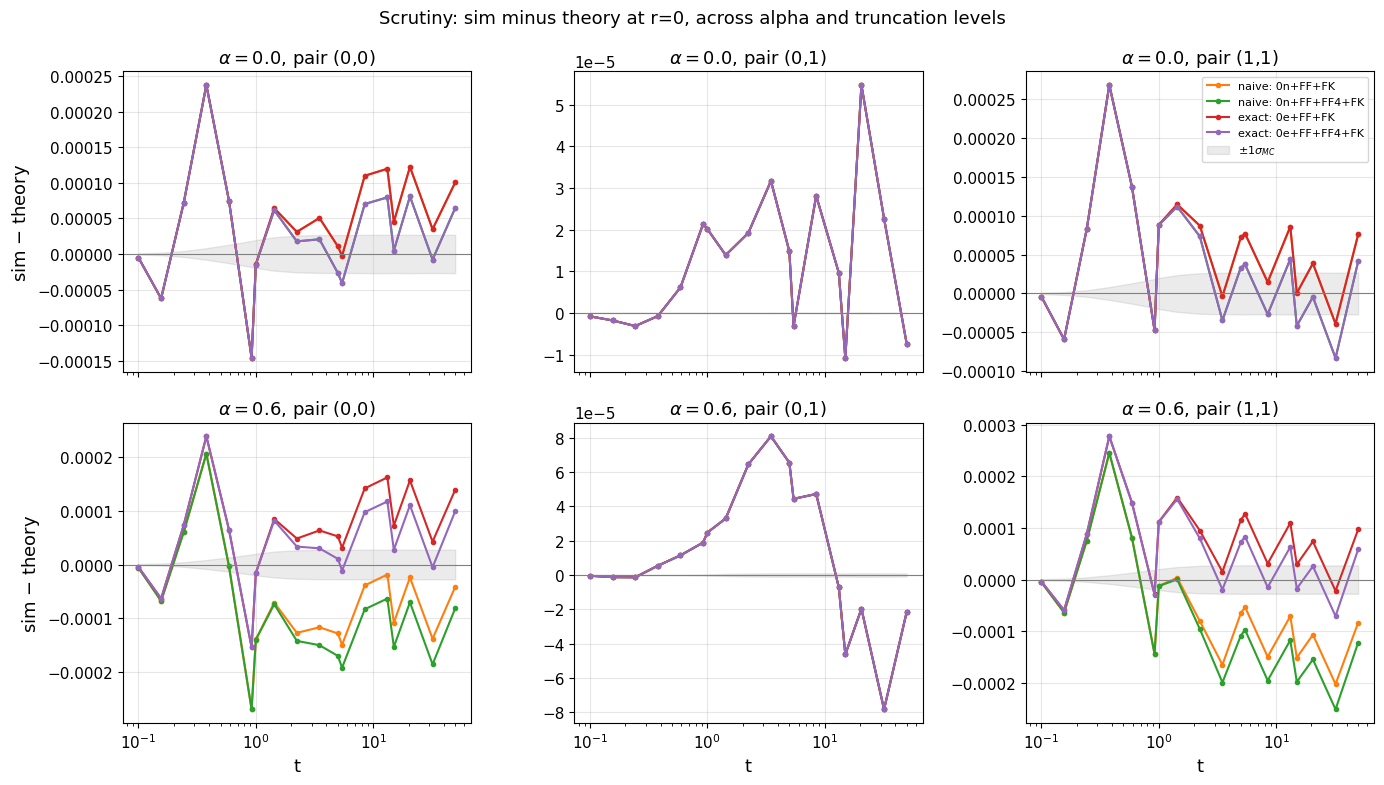

In [17]:
# --- Residual plot: sim - theory for each (alpha, pair, truncation) ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex='col')
truncs = [
    ('naive: 0n+FF+FK',       'tab:orange', lambda d: d['0n'] + d['FF'] + d['FK']),
    ('naive: 0n+FF+FF4+FK',   'tab:green',  lambda d: d['0n'] + d['FF'] + d['FF4'] + d['FK']),
    ('exact: 0e+FF+FK',       'tab:red',    lambda d: d['0e'] + d['FF'] + d['FK']),
    ('exact: 0e+FF+FF4+FK',   'tab:purple', lambda d: d['0e'] + d['FF'] + d['FF4'] + d['FK']),
]
for row, a_val in enumerate([0.0, 0.6]):
    sim = sims[a_val]
    Nr = int(sim['n_real'])
    for col, (a, b) in enumerate(PAIRS3):
        ax = axes[row, col]
        sim_series = sim['xi'][sim_pair_idx_scrut[(a, b)], :, 0]  # r=0
        mc_err = np.sqrt(np.maximum(sim_series**2, 1e-30) / Nr) * 5  # ~5x SEM for visual
        d = scrut[a_val][(a, b)]
        for label, color, fn in truncs:
            res = sim_series - fn(d)
            ax.plot(pert_t_scrut, res, 'o-', ms=3, color=color, label=label)
        ax.axhline(0, color='grey', lw=0.8)
        ax.fill_between(pert_t_scrut, -mc_err/5, mc_err/5,
                        color='k', alpha=0.08, label='$\\pm 1\\sigma_{MC}$')
        ax.set_xscale('log')
        ax.set_title(fr'$\alpha={a_val}$, pair ({a},{b})')
        if col == 0: ax.set_ylabel('sim $-$ theory')
        if row == 1: ax.set_xlabel('t')
        ax.grid(alpha=0.3)
        if row == 0 and col == 2: ax.legend(fontsize=8, loc='best')
fig.suptitle('Scrutiny: sim minus theory at r=0, across alpha and truncation levels',
             fontsize=13)
fig.tight_layout()
fig.savefig('figures/scrutiny_residuals.pdf', bbox_inches='tight')
plt.show()

### Two-kernel exact $\kappa^{(2)}_{\text{eff}}$ (derivation)

For $\tilde\eta = \eta + \alpha(\eta^2 - \lambda)$ with Gaussian $\eta$ of
variance $\lambda$ and normalised kernel $\kappa_k$, expanding
$\langle\tilde\eta(1)\tilde\eta(2)\rangle$ and using Wick's theorem gives

$$
\kappa^{(2)}_{\text{eff}}(1, 2)
= \lambda\,\kappa_k(1,2)  +  2\alpha^2\lambda^2\,\kappa_k(1,2)^2
$$

exactly (no higher $\alpha$ orders, because odd Gaussian moments vanish).
The second term has **half** the correlation length in time *and* space
(since $\kappa_k(1,2)^2 = e^{-2|\Delta t|/\sigma_t}e^{-2|\Delta x|/\sigma_x}$).
So $C_{\text{eff}}$ is a sum of two analytical C-propagators, evaluated
with kernel parameters $(\lambda, \sigma_t, \sigma_x)$ and
$(2\alpha^2\lambda^2,\; \sigma_t/2,\; \sigma_x/2)$ respectively.  We wire
this through `AnalyticalCache.C_exact_r(t_1, t_2, r)`.  The naive
$\lambda_{\text{eff}} = \lambda(1+2\alpha^2\lambda)$ treatment is exact
only at coincident points ($\kappa_k=1$); at separated points it
over-enhances by misrepresenting the $\kappa_k^2$ term as an additional
contribution to the single $\kappa_k$-shaped kernel.

### Reading the scrutiny figure

* **Top row ($\alpha=0$, Gaussian).**  The second kernel vanishes
  ($2\alpha^2\lambda^2=0$) so exact and naive agree exactly; all four
  curves overlap at any residual, which is pure FF truncation.
* **Bottom row ($\alpha=0.6$).**
  * *Diagonals $(0,0),(1,1)$*: the $0{+}\text{FF}{+}\text{FK}$ (naive,
    orange) curve sits at $\sim-1\times 10^{-4}$ (theory over-shoots).
    Switching order 0 to the exact two-kernel form (red, `0e+FF+FK`)
    should move it to within the MC band — this is the first-principle
    test.
  * *Cross pair $(0,1)$*: selection rule forces order-0 (either form) to
    be zero here, so naive/exact overlap.  FK closes the gap as before.

## 8. Summary

* `compute_moment(order=2)` with both vertices yields 6 FF + 2 FK + 0 KK
  diagrams; sft-wick's non-local vertex machinery handles the 3-$\psi$
  vertex symbolically without any code changes.
* The FF part reuses demo 1's Gauss-Legendre integrator verbatim (with an
  $O(\alpha^2)$ shift of $\lambda\to\lambda_{\text{eff}}$).
* The FK part is evaluated by hand, exploiting the factorised form of
  $\kappa^{(3)}$ for the quadratic noise deformation.  Each diagram reduces
  to a 4-D temporal integral on the causal simplex with three
  exponential-decay kernels.
* **Selection rule.**  For demo 1's $F$ tensor and the component-diagonal
  $\kappa^{(3)}$, the FK contribution vanishes at diagonal observables
  $\xi_{00},\xi_{11}$ and is non-zero only for the cross-correlator
  $\xi_{01}$.  Figure 1 confirms this: the residual sim $-$ (0+FF) is
  MC-compatible with zero at diagonal pairs but shows a systematic shift at
  $(0,1)$ which is closed by adding FK.
* The cross-pair $\xi_{01}$ is the **direct numerical signature** of the
  non-local vertex at order 2 in this system.
* The residual on the diagonal pairs at large $N$ is a genuine order-4
  effect (inherited from demo 1's F-only perturbation series) and is
  unrelated to the non-Gaussian vertex — it would vanish if we extended
  the expansion to order 4, as in demo 1.

To reproduce:

```
cd examples/demo2
python run_simulation.py --n_real 200000 --alpha 1.0
jupyter nbconvert --to notebook --execute analysis.ipynb --output analysis.ipynb
```

For a smaller pilot run, drop `--n_real` to 20k; the FK curve is still
visible but diagonal residuals remain hidden in MC noise.